# Demand Forecasting

---

In [1]:
import holidays
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import sys


In [2]:
import sys
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data_processing import combine_raw_data

PROCESSED_CSV_PATH = PROJECT_ROOT / "data" / "processed" / "combined_demand.csv"

combine_raw_data()
df = pd.read_csv(PROCESSED_CSV_PATH, parse_dates=["SETTLEMENT_DATE"])

Successfully combined 5 files into: C:\Users\roodruh\Desktop\repos\neso-demand-forecasting\data\processed\combined_demand.csv


In [12]:
uk_holidays = holidays.UK(years=[2021, 2022, 2023, 2024, 2025])

df["IS_HOLIDAY"] = (
    df["SETTLEMENT_DATE"].dt.date.isin(uk_holidays).astype(int)
)

df["DAY_OF_WEEK"] = df["SETTLEMENT_DATE"].dt.dayofweek
df["DAY_OF_YEAR"] = df["SETTLEMENT_DATE"].dt.dayofyear


df["ND_LAG_48"] = df["ND"].shift(48)
df["ND_LAG_96"] = df["ND"].shift(96)
df["ND_LAG_336"] = df["ND"].shift(336)

df["ND_AVG_24H"] = df["ND"].shift(48).rolling(window=48).mean()
df["ND_AVG_7D"] = df["ND"].shift(48).rolling(window=336).mean()

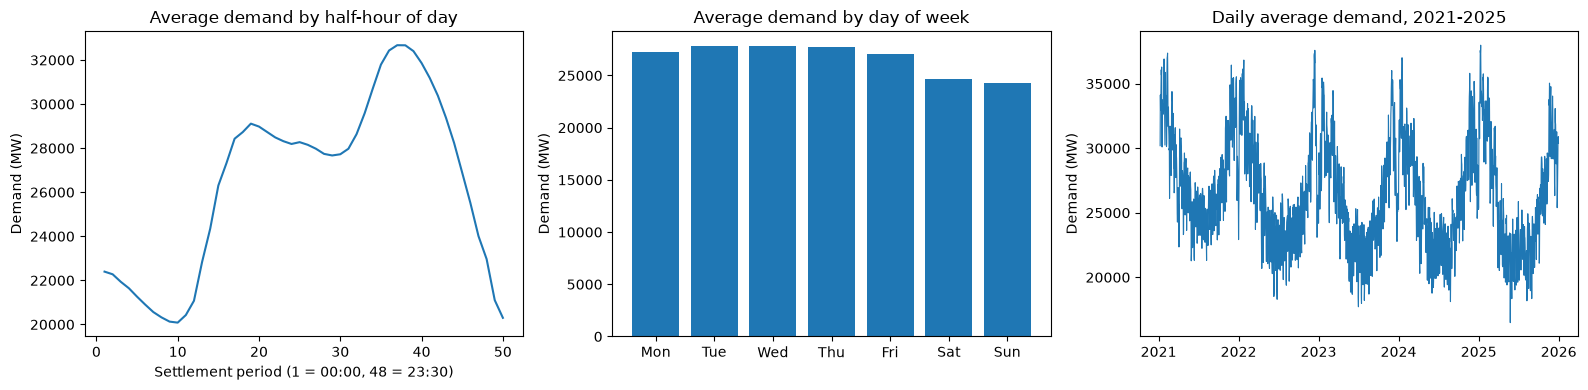

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

by_period = df.groupby("SETTLEMENT_PERIOD")["ND"].mean()
axes[0].plot(by_period.index, by_period.values)
axes[0].set_title("Average demand by half-hour of day")
axes[0].set_xlabel("Settlement period (1 = 00:00, 48 = 23:30)")
axes[0].set_ylabel("Demand (MW)")

day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
by_day = df.groupby("DAY_OF_WEEK")["ND"].mean()
axes[1].bar(day_names, by_day.values)
axes[1].set_title("Average demand by day of week")
axes[1].set_ylabel("Demand (MW)")

daily = df.groupby("SETTLEMENT_DATE")["ND"].mean()
axes[2].plot(daily.index, daily.values, linewidth=0.8)
axes[2].set_title("Daily average demand, 2021-2025")
axes[2].set_ylabel("Demand (MW)")

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "demand_patterns.png", dpi=150)
plt.show()

In [14]:
feature_cols = [
    "ND_LAG_48",
    "ND_LAG_96",
    "ND_LAG_336",
    "ND_AVG_24H",
    "ND_AVG_7D",
    "SETTLEMENT_PERIOD",
    "IS_HOLIDAY",
    "DAY_OF_WEEK",
    "DAY_OF_YEAR",
]

df = df.dropna(subset=feature_cols).reset_index(drop=True)

X = df[feature_cols]
y = df["ND"]

train = df["SETTLEMENT_DATE"].dt.year <= 2024
test  = df["SETTLEMENT_DATE"].dt.year == 2025
X_train, y_train = df.loc[train, feature_cols], df.loc[train, "ND"]
X_test,  y_test  = df.loc[test,  feature_cols], df.loc[test,  "ND"]

In [15]:
model = HistGradientBoostingRegressor(
    max_iter=1000,
    learning_rate=0.03,
    max_leaf_nodes=63,
    min_samples_leaf=50,
    max_bins=255,
    l2_regularization=1.0,
    early_stopping=True,
    n_iter_no_change=15,
    random_state=42
)
model.fit(X_train, y_train)

preds = model.predict(X_test)

In [16]:
mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
mape = np.mean(np.abs((y_test - preds) / y_test)) * 100
r2 = r2_score(y_test, preds)

print(f"MAE:   {mae:.2f}")
print(f"RMSE:  {rmse:.2f}")
print(f"MAPE:  {mape:.2f}%")
print(f"R²:    {r2:.4f}")

MAE:   1328.33
RMSE:  1790.73
MAPE:  5.35%
R²:    0.9158


In [17]:
# checking which features are important
from sklearn.inspection import permutation_importance

result = permutation_importance(
    model, X_test, y_test, n_repeats=10, random_state=42
)

importances = pd.Series(result.importances_mean, index=X_train.columns)
print(importances.sort_values(ascending=False))

ND_LAG_48            0.569057
DAY_OF_WEEK          0.111072
ND_LAG_336           0.106253
SETTLEMENT_PERIOD    0.063994
DAY_OF_YEAR          0.044056
ND_LAG_96            0.028813
ND_AVG_24H           0.010674
ND_AVG_7D            0.009384
IS_HOLIDAY           0.002175
dtype: float64


In [18]:
baselines = {
    "Model": preds,
    "Same time yesterday": X_test["ND_LAG_48"],
    "Same time last week": X_test["ND_LAG_336"],
}

rows = []
for name, p in baselines.items():
    rows.append({
        "Method": name,
        "MAPE (%)": round(np.mean(np.abs((y_test - p) / y_test)) * 100, 2),
        "MAE (MW)": round(mean_absolute_error(y_test, p)),
    })

results = pd.DataFrame(rows)
print(results.to_string(index=False))

             Method  MAPE (%)  MAE (MW)
              Model      5.35      1328
Same time yesterday      7.36      1846
Same time last week      8.47      2186


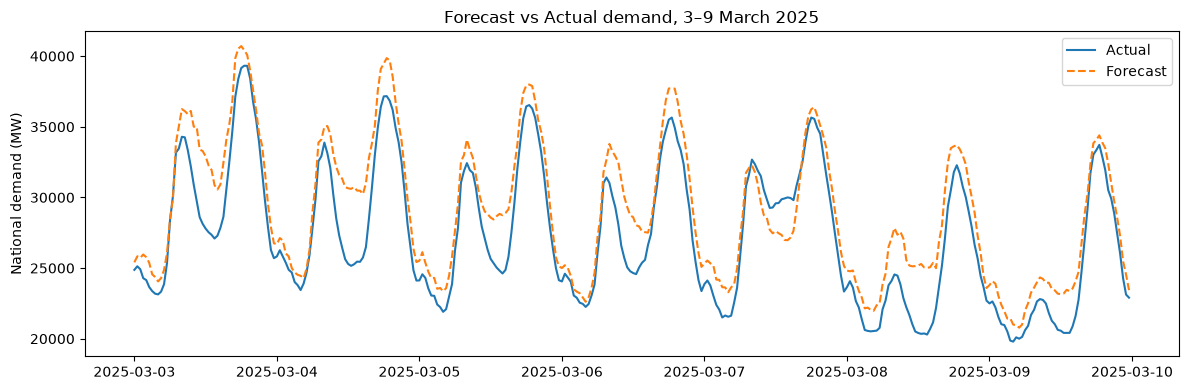

In [19]:
plot_df = df.loc[test, ["SETTLEMENT_DATE", "SETTLEMENT_PERIOD"]].copy()
plot_df["actual"] = y_test.values
plot_df["forecast"] = preds
plot_df["time"] = plot_df["SETTLEMENT_DATE"] + pd.to_timedelta((plot_df["SETTLEMENT_PERIOD"] - 1) * 30, unit="min")

week = plot_df[(plot_df["time"] >= "2025-03-03") & (plot_df["time"] < "2025-03-10")]

plt.figure(figsize=(12, 4))
plt.plot(week["time"], week["actual"], label="Actual")
plt.plot(week["time"], week["forecast"], label="Forecast", linestyle="--")
plt.ylabel("National demand (MW)")
plt.title("Forecast vs Actual demand, 3–9 March 2025")
plt.legend()
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "forecast_vs_actual.png", dpi=150)
plt.show()

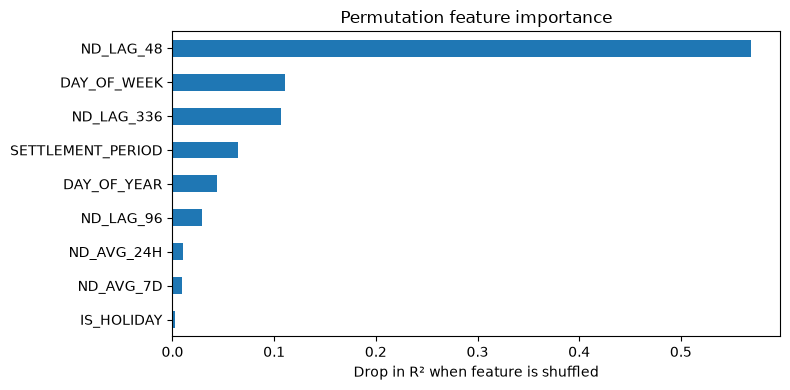

In [20]:
importances.sort_values().plot(kind="barh", figsize=(8, 4))
plt.xlabel("Drop in R² when feature is shuffled")
plt.title("Permutation feature importance")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "feature_importance.png", dpi=150)
plt.show()